Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Loading dataset

In [2]:
PROJECT_ROOT = Path.cwd().parent
METADATA_PATH = PROJECT_ROOT / "data" / "raw" / "PlantSeg" / "Metadata.csv"

df = pd.read_csv(METADATA_PATH)

EDA

In [3]:
df.head()

,Name,Index,Plant,Disease,Resolution,Label file,Mask ratio,URL,License,Split
0,apple_black_rot_1.jpg,0,Apple,apple black rot,640x480,apple_black_rot_1.png,0.040439,https://baijiahao.baidu.com/s?id=1592172448991...,CC-BY-NC,Training
1,apple_black_rot_11.jpg,0,Apple,apple black rot,1080x755,apple_black_rot_11.png,0.057550,http://dy.163.com/v2/article/detail/EJ3OGOG605...,CC-BY-NC,Training
2,apple_black_rot_12.jpg,0,Apple,apple black rot,1280x719,apple_black_rot_12.png,0.024791,http://baijiahao.baidu.com/s?id=16205160930871...,CC-BY-NC,Training
3,apple_black_rot_15.jpg,0,Apple,apple black rot,600x355,apple_black_rot_15.png,0.236169,http://www.360doc.cn/article/4310958_180040780...,CC-BY-NC,Training
4,apple_black_rot_156.jpg,0,Apple,apple black rot,219x294,apple_black_rot_156.png,0.054344,http://baijiahao.baidu.com/s?id=16352401074244...,CC-BY-NC,Training


In [4]:
#Dataset Dimentions
print(f"Shape : {df.shape}")
print(f"Columns : {df.shape[1]}") #can use df.columns to get the column names
print(f"Rows : {df.shape[0]}") #can use df.index to get the row names

Shape : (7774, 10)
Columns : 10
Rows : 7774


In [5]:
df.dtypes

Name              str
Index           int64
Plant             str
Disease           str
Resolution        str
Label file        str
Mask ratio    float64
URL               str
License           str
Split             str
dtype: object

In [6]:
#missing values
df.isnull().sum()

Name          0
Index         0
Plant         0
Disease       0
Resolution    0
Label file    0
Mask ratio    0
URL           0
License       0
Split         0
dtype: int64

Understand categorical variables

In [7]:
print("Unique plants:", df["Plant"].nunique())
print("Unique diseases:", df["Disease"].nunique())
print("Unique splits:", df["Split"].nunique())

Unique plants: 34
Unique diseases: 115
Unique splits: 3


In [8]:
df["Split"].value_counts()

Split
Training      5367
Test          1561
Validation     846
Name: count, dtype: int64

Investigate class imbalance

In [16]:
disease_counts = df["Disease"].value_counts()

print("Total diseases ", len(disease_counts))
print("Disease with highest count: ", disease_counts.max())
print("Disease with lowest count: ", disease_counts.min())
print("Average disease count : ", round(disease_counts.mean(),2))

Total diseases  115
Disease with highest count:  323
Disease with lowest count:  3
Average disease count :  67.6


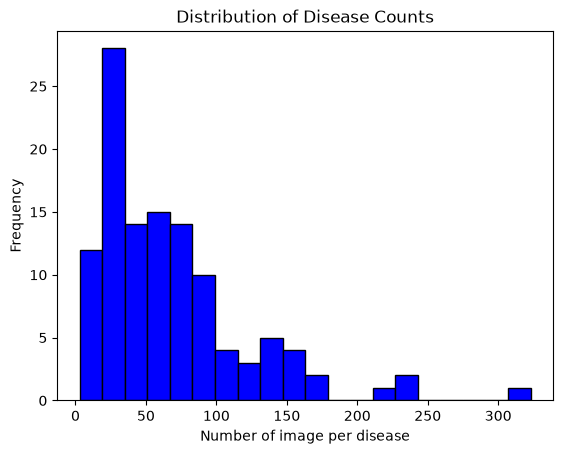

In [18]:
#plt.figure(figsize=(12,6))
plt.hist(disease_counts,bins=20, color='blue', edgecolor='black')
plt.title("Distribution of Disease Counts")
plt.xlabel("Number of image per disease")
plt.ylabel("Frequency")
plt.show()